🎯 Objective:
Does the release month of a movie significantly affect its box office revenue?

🗃️ Suggested Dataset:
Use tn.movie_budgets.csv.gz or bom.movie_gross.csv.gz (they both have revenue and release date)

Extract the release month from the release_date or year columns

🔬 Hypothesis:
H₀: There is no significant difference in average box office revenue between movies released in different months.
H₁: At least one month has significantly different average revenue.

Use One-Way ANOVA to test across 12 months.

Optionally, apply post-hoc tests like Tukey’s HSD if the ANOVA is significant to identify which months are different.

📈 Regression Option:
Fit a linear regression model:

python
Copy
Edit
worldwide_gross ~ C(release_month) + production_budget
This tells you if release timing, even after accounting for budget, still plays a role in revenue.

💡 Business Value:
Reveals which months are most profitable for new releases—vital for scheduling production and distribution. Your studio might aim for summer (blockbusters) or December (holiday releases), or find an untapped opportunity in quieter months.

In [1]:
!ls

README.md
movie_market_analysis.ipynb
release_mon_analysis.ipynb
zippedData


In [2]:
!ls zippedData/

bom.movie_gross.csv.gz
im.db.zip
rt.movie_info.tsv.gz
rt.reviews.tsv.gz
tmdb.movies.csv.gz
tn.movie_budgets.csv.gz


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)

In [4]:
budgets_df = pd.read_csv("zippedData/tn.movie_budgets.csv.gz")
budgets_df.head()


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [5]:
budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


In [6]:
budgets_df.describe()

,id
count,5782.000000
mean,50.372363
std,28.821076
min,1.000000
25%,25.000000
50%,50.000000
75%,75.000000
max,100.000000


In [7]:
cols_to_clean = ['production_budget', 'domestic_gross', 'worldwide_gross']

for col in cols_to_clean:
    budgets_df[col] = budgets_df[col].replace('[\$,]', '', regex=True).astype(float)

budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5782 non-null   int64  
 1   release_date       5782 non-null   object 
 2   movie              5782 non-null   object 
 3   production_budget  5782 non-null   float64
 4   domestic_gross     5782 non-null   float64
 5   worldwide_gross    5782 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 271.2+ KB


In [8]:
budgets_df['release_date'] = pd.to_datetime(budgets_df['release_date'], errors='coerce')
budgets_df['release_year'] = budgets_df['release_date'].dt.year
budgets_df['release_month'] = budgets_df['release_date'].dt.month
budgets_df.head(20)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_year,release_month
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,2009,12
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,2011,5
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,2019,6
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,2015,5
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,2017,12
5,6,2015-12-18,Star Wars Ep. VII: The Force Awakens,306000000.0,936662225.0,2.053311e+09,2015,12
6,7,2018-04-27,Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,2018,4
7,8,2007-05-24,Pirates of the Caribbean: At Worldâs End,300000000.0,309420425.0,9.634204e+08,2007,5
8,9,2017-11-17,Justice League,300000000.0,229024295.0,6.559452e+08,2017,11
9,10,2015-11-06,Spectre,300000000.0,200074175.0,8.796209e+08,2015,11


In [9]:
budgets_df.describe()

,id,production_budget,domestic_gross,worldwide_gross,release_year,release_month
count,5782.000000,5.782000e+03,5.782000e+03,5.782000e+03,5782.000000,5782.000000
mean,50.372363,3.158776e+07,4.187333e+07,9.148746e+07,2003.967139,7.050675
std,28.821076,4.181208e+07,6.824060e+07,1.747200e+08,12.724386,3.480147
min,1.000000,1.100000e+03,0.000000e+00,0.000000e+00,1915.000000,1.000000
25%,25.000000,5.000000e+06,1.429534e+06,4.125415e+06,2000.000000,4.000000
50%,50.000000,1.700000e+07,1.722594e+07,2.798445e+07,2007.000000,7.000000
75%,75.000000,4.000000e+07,5.234866e+07,9.764584e+07,2012.000000,10.000000
max,100.000000,4.250000e+08,9.366622e+08,2.776345e+09,2020.000000,12.000000


In [10]:
budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5782 non-null   int64         
 1   release_date       5782 non-null   datetime64[ns]
 2   movie              5782 non-null   object        
 3   production_budget  5782 non-null   float64       
 4   domestic_gross     5782 non-null   float64       
 5   worldwide_gross    5782 non-null   float64       
 6   release_year       5782 non-null   int64         
 7   release_month      5782 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(1)
memory usage: 361.5+ KB


## Distribution of production_budget and worldwide_gross

Simple Questions You Can Try Answering
What is the average production budget and gross revenue?

Are there months where more movies are released?

Do movies with higher budgets tend to earn more?

Are movie revenues normally distributed or skewed?

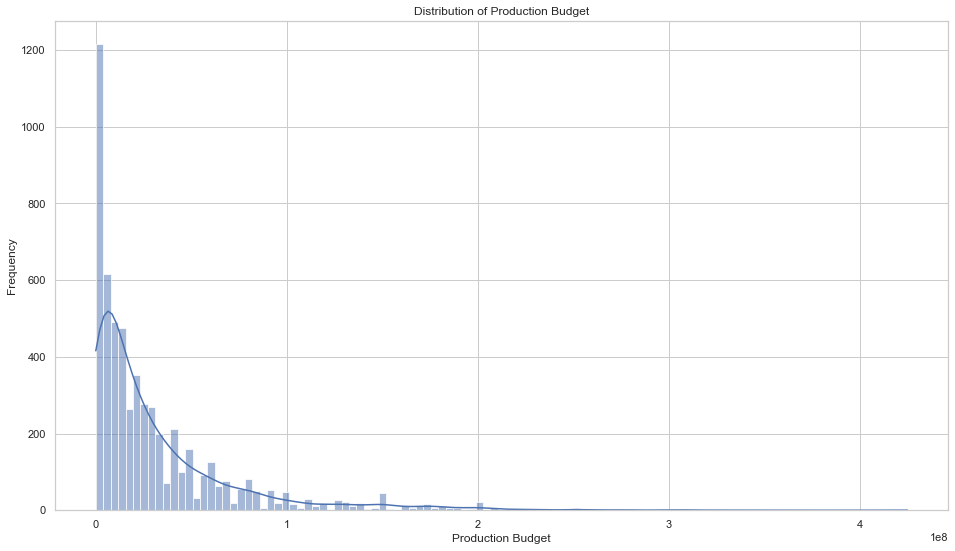

In [11]:

#distribution of Production Budget
sns.histplot(budgets_df['production_budget'], kde=True)
plt.title('Distribution of Production Budget')
plt.xlabel('Production Budget')
plt.ylabel('Frequency')
plt.show()

this seems to be the distribution of production_budget. Similar to worldwide_gross, it likely shows:

A right-skewed distribution with a few high-budget movies.

Possible transformation (like log) could stabilize variance in later models.

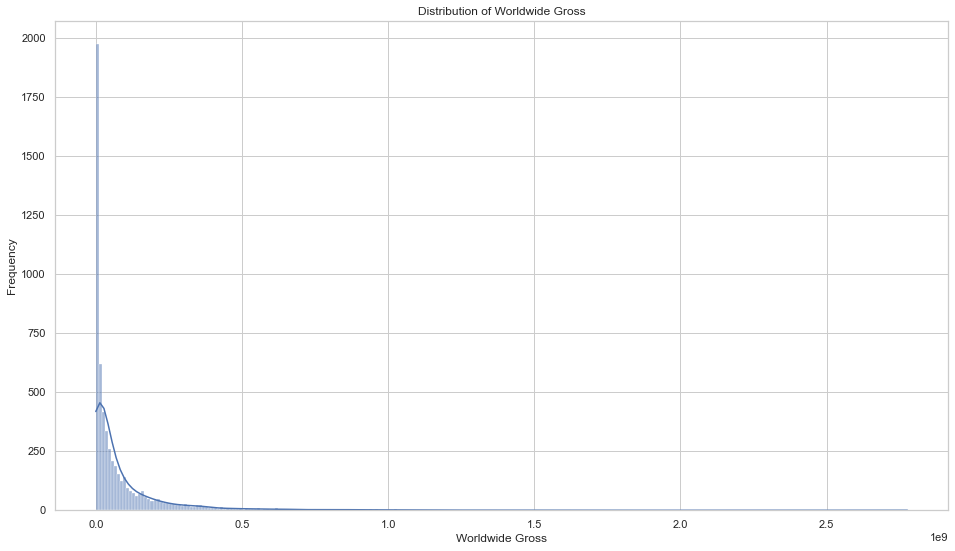

In [12]:
#distribution of Worldwide Gross
sns.histplot(budgets_df['worldwide_gross'], kde=True)
plt.title('Distribution of Worldwide Gross')
plt.xlabel('Worldwide Gross')
plt.ylabel('Frequency')
plt.show()

1. dist_world.PNG
This appears to be a histogram or KDE plot of the worldwide_gross column. From this plot, we can observe:

The distribution of worldwide gross is heavily right-skewed (i.e., most movies make modest revenue, but a few blockbusters make a lot).

This skewness justifies the idea of normalization or log transformation before running models or tests that assume normality.

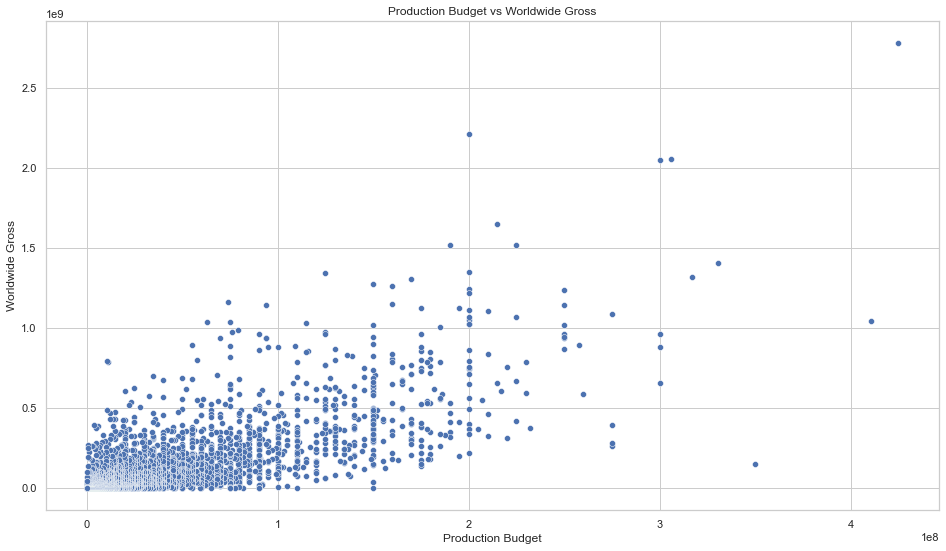

In [13]:
#Scatterplot: Production Budget vs Worldwide Gross
sns.scatterplot(data=budgets_df, x='production_budget', y='worldwide_gross')
plt.title('Production Budget vs Worldwide Gross')
plt.xlabel('Production Budget')
plt.ylabel('Worldwide Gross')
plt.show()

This is likely a scatter plot of production_budget vs worldwide_gross. Key insights:

There appears to be a positive relationship—higher production budgets often lead to higher gross revenue.

However, the spread may increase with budget, suggesting heteroscedasticity (variance not being constant).

Outliers are visible—very high budget movies that earned much more or much less than expected.

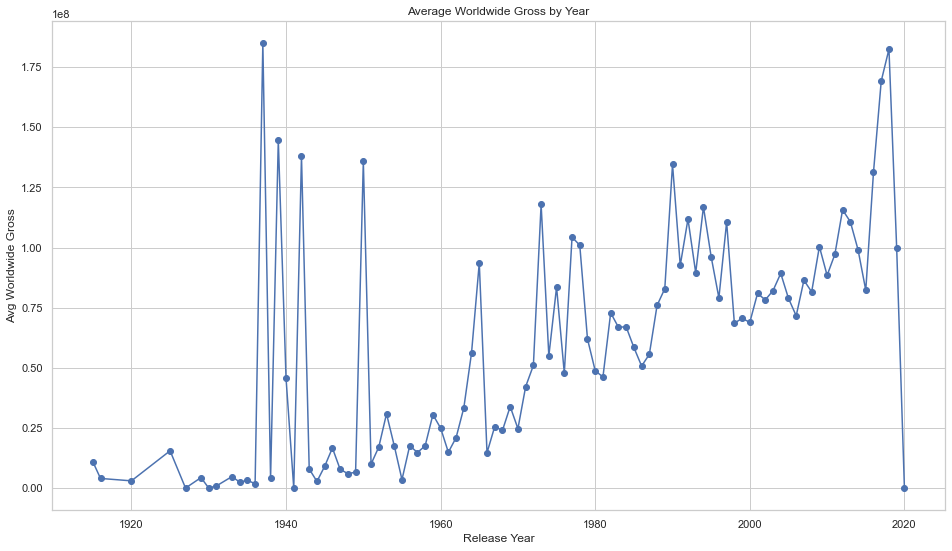

In [14]:
#Line Plot: Average Worldwide Gross by Year
avg_gross_by_year = budgets_df.groupby('release_year')['worldwide_gross'].mean()
avg_gross_by_year.plot(kind='line', marker='o')
plt.title('Average Worldwide Gross by Year')
plt.ylabel('Avg Worldwide Gross')
plt.xlabel('Release Year')
plt.grid(True)
plt.show()

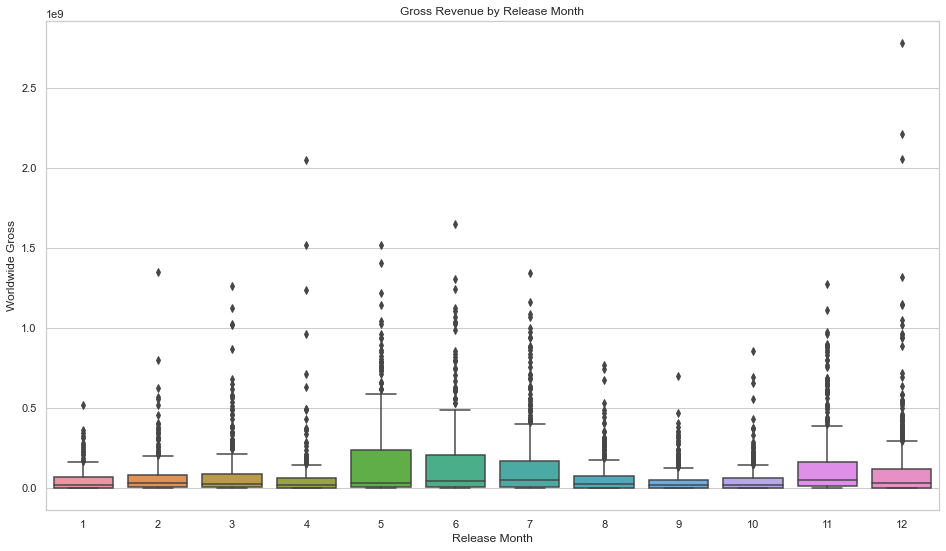

In [15]:
sns.boxplot(data=budgets_df, x='release_month', y='worldwide_gross')
plt.title('Gross Revenue by Release Month')
plt.xlabel('Release Month')
plt.ylabel('Worldwide Gross')
plt.show()

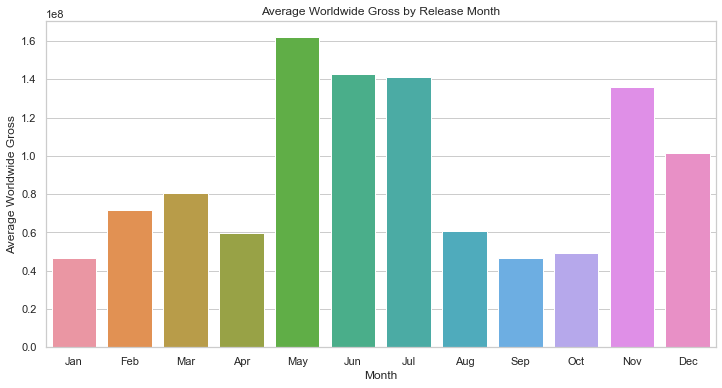

In [16]:
import calendar

#Group by release_month and calculate mean worldwide_gross
monthly_avg_gross = budgets_df.groupby('release_month')['worldwide_gross'].mean()

#Sort months in calendar order
monthly_avg_gross = monthly_avg_gross.reindex(range(1, 13))

#Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_avg_gross.index, y=monthly_avg_gross.values)
plt.xticks(ticks=range(0, 12), labels=[calendar.month_abbr[i+1] for i in range(12)])
plt.title('Average Worldwide Gross by Release Month')
plt.xlabel('Month')
plt.ylabel('Average Worldwide Gross')
plt.show()

# Stats

In [19]:
budgets_df['log_worldwide_gross'] = np.log1p(budgets_df['worldwide_gross'])
budgets_df['log_production_budget'] = np.log1p(budgets_df['production_budget'])


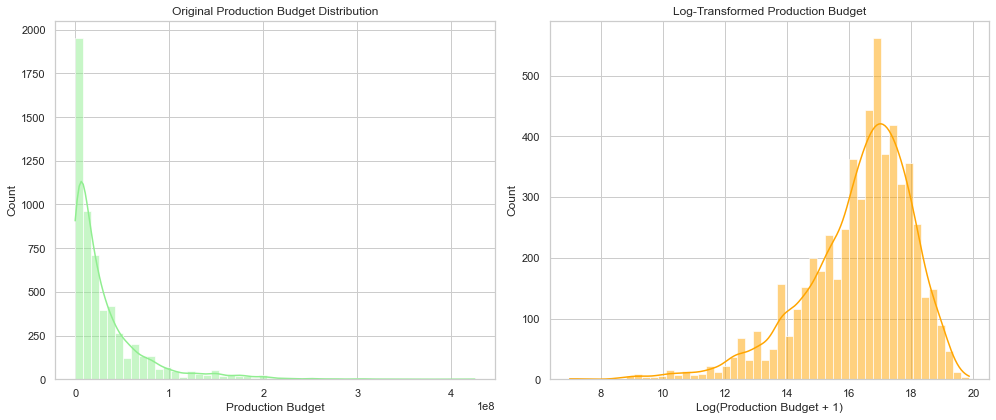

In [22]:
plt.figure(figsize=(14, 6))

# Original production budget distribution
plt.subplot(1, 2, 1)
sns.histplot(budgets_df['production_budget'], bins=50, kde=True, color='lightgreen')
plt.title('Original Production Budget Distribution')
plt.xlabel('Production Budget')

# Log-transformed production budget
plt.subplot(1, 2, 2)
sns.histplot(budgets_df['log_production_budget'], bins=50, kde=True, color='orange')
plt.title('Log-Transformed Production Budget')
plt.xlabel('Log(Production Budget + 1)')

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Log(Worldwide Gross + 1)')

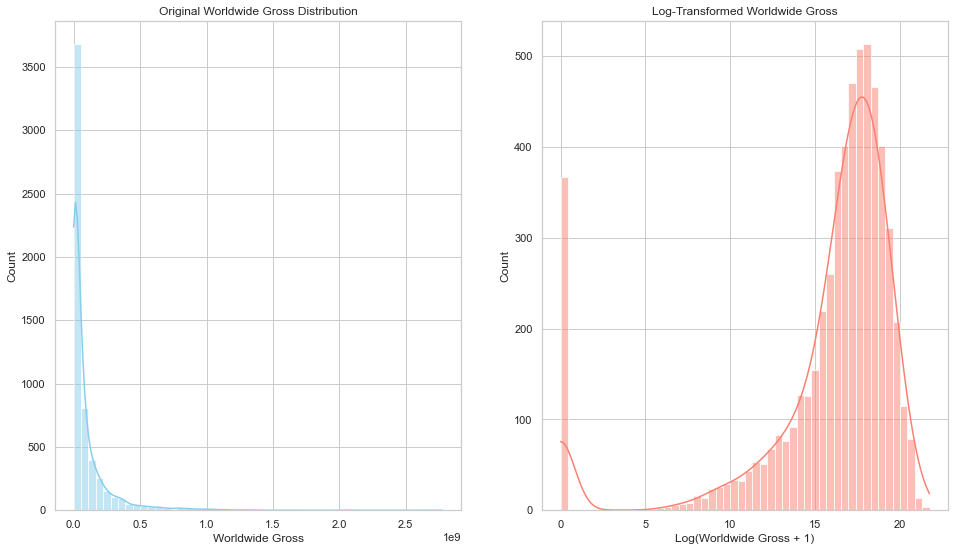

In [21]:
plt.subplot(1, 2, 1)
sns.histplot(budgets_df['worldwide_gross'], bins=50, kde=True, color='skyblue')
plt.title('Original Worldwide Gross Distribution')
plt.xlabel('Worldwide Gross')

# Log-transformed
plt.subplot(1, 2, 2)
sns.histplot(budgets_df['log_worldwide_gross'], bins=50, kde=True, color='salmon')
plt.title('Log-Transformed Worldwide Gross')
plt.xlabel('Log(Worldwide Gross + 1)')

In [24]:
# Grouping the data
groups = [group['log_worldwide_gross'].values for name, group in budgets_df.groupby('release_month')]

# Run One-Way ANOVA
f_stat, p_val = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}, p-value: {p_val:.7f}")

F-statistic: 12.209, p-value: 0.0000000


In [26]:
import statsmodels.formula.api as smf

model = smf.ols('z_worldwide_gross ~ C(release_month) + z_production_budget', data=budgets_df).fit()
print(model.summary())


PatsyError: Error evaluating factor: NameError: name 'z_worldwide_gross' is not defined
    z_worldwide_gross ~ C(release_month) + z_production_budget
    ^^^^^^^^^^^^^^^^^